# Chapter 5 - Pattern-Oriented Validation

This notebook runs seven validation tests on the labour-market ABM. Each test asks the same kind of question: *if we change one knob in the model, does the outcome move in the direction that economic theory predicts?*

At the end there is a summary table.

| # | Pattern | Quick description |
|---|---|---|
| 1 | Profitability gate | Loss-making firms should stop proactive automation |
| 2 | AI cost | Expensive AI is adopted less often |
| 3 | Severance | Higher firing cost should slow AI adoption |
| 4 | Demand decline | Job losses should drop aggregate demand |
| 5 | Minimum wage | Higher wage floor pushes firms to automate |
| 6 | Polarisation | AI hitting routine tasks hurts low-skilled workers most |


## Setup

Imports, find the repo root, load the model, and define a tiny `run_sims` helper that runs the model `N_REPS` times and gives us back a list of dataframes (one per replication).


In [1]:
import os, sys, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats, optimize

warnings.filterwarnings('ignore', category=RuntimeWarning)

# --- find the repo so we can import the model -------------------------
def find_repo_root(start):
    for p in [start, *start.parents]:
        if (p / 'model' / 'labour_market_model.py').exists():
            return p
    raise FileNotFoundError('Cannot find repo root')

REPO_ROOT = find_repo_root(Path.cwd().resolve())
sys.path.insert(0, str(REPO_ROOT / 'model'))
from labour_market_model import LabourMarketModel
from base_parameters import BASE_PARAMS

FIG_DIR = REPO_ROOT / 'notebooks' / 'validation' / 'validation_figures'
FIG_DIR.mkdir(exist_ok=True)

# --- compute budget --------------------------------------------------
N_REPS  = 12     # number of replications per regime (different random seeds)
N_STEPS = 960    # 80 simulated years at 12 steps per year

# --- the two scenarios used in the chapter ---------------------------
# A = no institutions (reference for the verification of the institution effect, see Ch 5.3)
# B = Dutch baseline (the one we focus on -- all 7 pattern tests run on B)
SCENARIO_A = dict(adoption_mode='npv_naive',      employment_protection=False, w_min=0.0, lam=1.0)
SCENARIO_B = dict(adoption_mode='npv_mean_field', employment_protection=True)

# --- helper: run the model n_reps times with given parameter overrides
def run_sims(overrides, n_reps=N_REPS, n_steps=N_STEPS, seed_base=1000):
    """Run n_reps simulations and return a list of model dataframes."""
    results = []
    for r in range(n_reps):
        params = BASE_PARAMS.copy()
        params.update(overrides)
        params['seed'] = seed_base + r
        m = LabourMarketModel(**params)
        for _ in range(n_steps):
            m.step()
        results.append(m.datacollector.get_model_vars_dataframe().reset_index(drop=True))
    return results

def save_fig(fig, name):
    path = FIG_DIR / name
    fig.savefig(path, dpi=150, bbox_inches='tight')
    print(f'  figure saved: {path.name}')

# container for the final summary table
VERDICTS = {}

print(f'Setup OK. N_REPS={N_REPS}, N_STEPS={N_STEPS}')
print(f'Figures go to: {FIG_DIR}')

Setup OK. N_REPS=12, N_STEPS=960
Figures go to: C:\<repo>\notebooks\validation\validation_figures


---
## Pattern 1 - Profitability gate

**What we test.** If production suddenly becomes extremely expensive, does the model stop automation and expansion?

**Mechanism.** The producer expansion rule is gated by profitability. A firm only generates proactive bottleneck-expansion requests when its average cost is below the goods-market price:
$$AC_i < p$$
If $AC_i \geq p$, expanding output would deepen operating losses, so the producer should not proactively hire or automate bottleneck tasks. Reactive replacement after worker separations is a separate channel and is deliberately switched off in this test.

**How.** In each replication we run the Dutch baseline to a fixed shock step with exogenous separations switched off and `p_convert=1`, so workers do not leave tasks through random separations or chain-limit non-renewal. This keeps the warm-start allocation occupied by either workers or already-installed AI, so the test does not mix the profitability gate with empty-slot recovery. At the shock step we set both wages and the AI rental price to extremely high values. This pushes producers' average costs above the goods-market price.

**Pass criterion.** After the shock, producers are loss-making ($AC > p$ and average profit is negative), the profitability gate blocks expansion, and no new automation occurs.


  figure saved: fig_5_1_profitability_gate.png


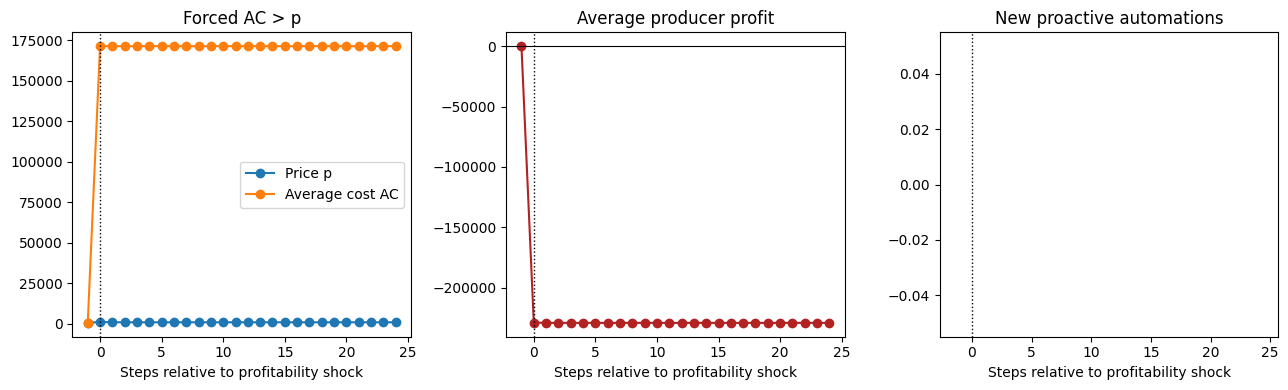


Profitability shock:
  shock step: 240; wage shock: 10000; AI cost shock: 10000
  Share of post-shock observations with avg AC > p: 100.00%
  Share of post-shock observations with negative average profit: 100.00%
  Mean gate blocks per post-shock step: 20.00
  New automations after shock: 0
  New proactive automations after shock: 0

Post-shock automation trace: none

PASS - Pattern 1


In [2]:
PROFIT_SHOCK_STEP = N_STEPS // 4
PROFIT_POST_STEPS = 24
WAGE_SHOCK = 10_000.0
AI_COST_SHOCK = 10_000.0

def producer_average_costs(m):
    return [p.total_costs / p.output for p in m.producers if p.output > 0]

def refresh_profitability_state(m):
    """Recalculate output, price and diagnostics after an out-of-step cost shock."""
    for p in m.producers:
        p.produce()
        p.trim_ai_capacity()
    m.Y = m.calculate_wage_bill()
    m.Pi = m.calculate_profit_income()
    m.p = m.calculate_market_price()
    m._compute_all_stats()

def profitability_snapshot(m, rep, horizon, label):
    ac = producer_average_costs(m)
    return {
        'rep': rep,
        'horizon': horizon,
        'label': label,
        'price': m.p,
        'avg_AC': float(np.mean(ac)) if ac else np.nan,
        'share_unprofitable': float(np.mean([x > m.p for x in ac])) if ac else np.nan,
        'avg_profit': m._step_stats.get('avg_profit', np.nan),
        'n_gate_blocks': m.n_gate_blocks_this_step,
        'new_automations': m._step_stats.get('new_automations_this_step', 0.0),
        'new_proactive_automations': m.new_proactive_automations_this_step,
        'ai_adoption_rate': m._step_stats.get('ai_adoption_rate', np.nan),
    }

def trace_new_automations(m, rep, horizon):
    """Return detailed records for automation decisions made in the current model step."""
    rows = []
    by_id = {p.unique_id: p for p in m.producers}
    for rec in m.investment_log:
        if rec.get('step') != m.current_step or not rec.get('decision'):
            continue
        producer = by_id.get(rec.get('producer_id'))
        output = producer.output if producer is not None else np.nan
        total_costs = producer.total_costs if producer is not None else np.nan
        ac = total_costs / output if output and output > 0 else np.nan
        rows.append({
            'rep': rep,
            'horizon': horizon,
            'model_step': m.current_step,
            'producer_id': rec.get('producer_id'),
            'task_id': rec.get('task_id'),
            'task_type': rec.get('task_type'),
            'complexity': rec.get('complexity'),
            'channel': rec.get('channel'),
            'producer_output': output,
            'producer_AC': ac,
            'price': m.p,
            'output_zero_gate_bypass': bool(output <= 0) if not np.isnan(output) else False,
            'npv': rec.get('npv'),
            'hurdle_threshold': rec.get('hurdle_threshold'),
            'uc_human_now': rec.get('uc_human_now'),
            'uc_ai_now': rec.get('uc_ai_now'),
            'decision_reason': rec.get('decision_reason'),
        })
    return rows

def force_profitability_shock(m):
    """Make labour and AI inputs extremely expensive from this step onward."""
    m.w_min = WAGE_SHOCK
    m.w_h = WAGE_SHOCK
    m.w_l = WAGE_SHOCK
    m.w_h_prev = WAGE_SHOCK
    m.w_l_prev = WAGE_SHOCK
    m.k_ai = AI_COST_SHOCK
    m.k_ai_0 = AI_COST_SHOCK
    m.k_ai_floor = AI_COST_SHOCK
    m.k_ai_decay = 0.0
    for w in m.workers:
        if w.employed:
            w.wage = WAGE_SHOCK
    for p in m.producers:
        p._pending_requests = []
    refresh_profitability_state(m)

profit_records = []
automation_trace = []
for r in range(N_REPS):
    params = BASE_PARAMS.copy()
    params.update(SCENARIO_B)
    params.update({
        'delta': 0.0,           # keep warm-start jobs from disappearing before the shock
        'p_convert': 1.0,       # chain-limit workers convert instead of leaving vacancies
        'p_evaluate': 1.0,      # make the proactive channel observable if the gate is open
        'log_decisions': True,
        'seed': 1100 + r,
    })
    m = LabourMarketModel(**params)

    for _ in range(PROFIT_SHOCK_STEP):
        m.step()
    refresh_profitability_state(m)
    profit_records.append(profitability_snapshot(m, r, -1, 'pre-shock'))

    force_profitability_shock(m)
    profit_records.append(profitability_snapshot(m, r, 0, 'forced AC > p'))

    for h in range(1, PROFIT_POST_STEPS + 1):
        m.step()
        automation_trace.extend(trace_new_automations(m, r, h))
        profit_records.append(profitability_snapshot(m, r, h, 'post-shock'))

profit_df = pd.DataFrame(profit_records)
plot_df = profit_df.groupby('horizon', as_index=False).mean(numeric_only=True)
post = profit_df[profit_df['horizon'] >= 1]

fig, ax = plt.subplots(1, 3, figsize=(13, 4))
ax[0].plot(plot_df['horizon'], plot_df['price'], marker='o', label='Price p')
ax[0].plot(plot_df['horizon'], plot_df['avg_AC'], marker='o', label='Average cost AC')
ax[0].axvline(0, color='black', ls=':', lw=1)
ax[0].set_xlabel('Steps relative to profitability shock')
ax[0].set_title('Forced AC > p')
ax[0].legend()

ax[1].plot(plot_df['horizon'], plot_df['avg_profit'], marker='o', color='firebrick')
ax[1].axhline(0, color='black', lw=0.8)
ax[1].axvline(0, color='black', ls=':', lw=1)
ax[1].set_xlabel('Steps relative to profitability shock')
ax[1].set_title('Average producer profit')

ax[2].bar(plot_df['horizon'], plot_df['new_proactive_automations'], color='steelblue')
ax[2].axvline(0, color='black', ls=':', lw=1)
ax[2].set_xlabel('Steps relative to profitability shock')
ax[2].set_title('New proactive automations')

plt.tight_layout(); save_fig(fig, 'fig_5_1_profitability_gate.png'); plt.show()

post_avg_ac_gt_price = (post['avg_AC'] > post['price']).mean()
post_profit_negative = (post['avg_profit'] < 0).mean()
post_gate_blocks = post['n_gate_blocks'].mean()
post_new_auto = post['new_automations'].sum()
post_new_proactive = post['new_proactive_automations'].sum()
trace_df = pd.DataFrame(automation_trace)

print('\nProfitability shock:')
print(f'  shock step: {PROFIT_SHOCK_STEP}; wage shock: {WAGE_SHOCK:.0f}; AI cost shock: {AI_COST_SHOCK:.0f}')
print(f'  Share of post-shock observations with avg AC > p: {post_avg_ac_gt_price:.2%}')
print(f'  Share of post-shock observations with negative average profit: {post_profit_negative:.2%}')
print(f'  Mean gate blocks per post-shock step: {post_gate_blocks:.2f}')
print(f'  New automations after shock: {post_new_auto:.0f}')
print(f'  New proactive automations after shock: {post_new_proactive:.0f}')
if len(trace_df):
    print('\nPost-shock automation trace:')
    cols = ['rep', 'horizon', 'model_step', 'producer_id', 'task_id', 'task_type',
            'channel', 'producer_output', 'producer_AC', 'price',
            'output_zero_gate_bypass', 'npv', 'hurdle_threshold',
            'uc_human_now', 'uc_ai_now', 'decision_reason']
    print(trace_df[cols].to_string(index=False))
else:
    print('\nPost-shock automation trace: none')

verdict = (
    post_avg_ac_gt_price >= 0.95
    and post_profit_negative >= 0.95
    and post_gate_blocks > 0
    and post_new_proactive == 0
    and post_new_auto == 0
)
VERDICTS[1] = ('Profitability gate', 'forced AC > p stops proactive automation', verdict,
               f'AC>p share={post_avg_ac_gt_price:.0%}; profit<0 share={post_profit_negative:.0%}; '
               f'gate blocks={post_gate_blocks:.1f}/step; new proactive auto={post_new_proactive:.0f}')
print(f'\n{"PASS" if verdict else "FAIL"} - Pattern 1')

---
## Pattern 2 - Expensive AI is adopted less

**What we test.** If we make AI more expensive, do firms adopt it less?

**Two knobs we vary:**
- `k_ai_floor`: the minimum AI cost (higher = AI never gets really cheap)
- `k_ai_decay`: how fast AI gets cheaper over time (slower decay = stays expensive longer)

**Pass criterion.** Adoption goes monotonically down as `k_ai_floor` rises, and monotonically up as `k_ai_decay` gets faster.


  figure saved: fig_5_3_ai_cost.png


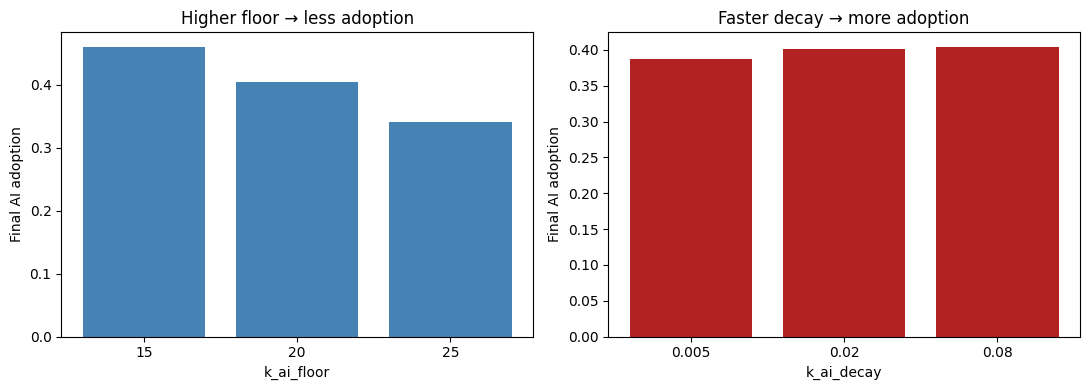


Final adoption by k_ai_floor: {15: np.float64(0.461), 20: np.float64(0.405), 25: np.float64(0.342)}
Final adoption by k_ai_decay: {0.005: np.float64(0.387), 0.02: np.float64(0.401), 0.08: np.float64(0.404)}

PASS - Pattern 2


In [3]:
k_floor_levels = [15, 20, 25]            # base is 20
k_decay_levels = [0.005, 0.020, 0.080]   # slow / base / fast

end_floor = {}
end_decay = {}
for kf in k_floor_levels:
    runs = run_sims({**SCENARIO_B, 'k_ai_floor': kf}, seed_base=1200)
    end_floor[kf] = np.mean([df['ai_adoption_rate'].iloc[-1] for df in runs])
for kd in k_decay_levels:
    runs = run_sims({**SCENARIO_B, 'k_ai_decay': kd}, seed_base=1300)
    end_decay[kd] = np.mean([df['ai_adoption_rate'].iloc[-1] for df in runs])

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].bar([str(k) for k in k_floor_levels], [end_floor[k] for k in k_floor_levels], color='steelblue')
ax[0].set_xlabel('k_ai_floor'); ax[0].set_ylabel('Final AI adoption')
ax[0].set_title('Higher floor → less adoption')
ax[1].bar([str(k) for k in k_decay_levels], [end_decay[k] for k in k_decay_levels], color='firebrick')
ax[1].set_xlabel('k_ai_decay'); ax[1].set_ylabel('Final AI adoption')
ax[1].set_title('Faster decay → more adoption')
plt.tight_layout(); save_fig(fig, 'fig_5_3_ai_cost.png'); plt.show()

print('\nFinal adoption by k_ai_floor:', {k: round(v, 3) for k, v in end_floor.items()})
print('Final adoption by k_ai_decay:', {k: round(v, 3) for k, v in end_decay.items()})

floor_ok = end_floor[15] >= end_floor[20] >= end_floor[25]
decay_ok = end_decay[0.005] <= end_decay[0.020] <= end_decay[0.080]
verdict = floor_ok and decay_ok
VERDICTS[2] = ('AI cost vs adoption', 'cheap AI → more adoption', verdict,
               f'floor monotone: {floor_ok}, decay monotone: {decay_ok}')
print(f'\n{"PASS" if verdict else "FAIL"} - Pattern 2')

---
## Pattern 3 - Severance slows automation

**What we test.** Severance pay (the cost a firm has to pay when firing a worker) should make automation more expensive and therefore slower.

**Caveat.** In this model the channel is mechanically small: most automation happens on *empty* slots (where there is nobody to pay severance to). So we expect only a weak effect at best - we just report what the simulation says.

**Pass criterion.** Adoption at high severance is *not higher* than at no severance (i.e. effect goes the expected direction, even if small).


In [ ]:
sev_levels = [0.0, 1/3, 1.0, 5.0, 20.0]   # no / base / high severance
sev_labels = ['0', '1/3', '1', '5', '20']
end_adoption = {}
for sev in sev_levels:
    runs = run_sims({**SCENARIO_B, 'severance_rate': sev, 'p_convert': 0.95, 'chain_limit': 2}, seed_base=1400)
    end_adoption[sev] = np.array([df['ai_adoption_rate'].iloc[-1] for df in runs])

means = {s: end_adoption[s].mean() for s in sev_levels}
stds  = {s: end_adoption[s].std()  for s in sev_levels}

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(sev_labels,
       [means[s] for s in sev_levels],
       yerr=[stds[s] for s in sev_levels],
       color='steelblue', capsize=4)
ax.set_xlabel('severance_rate (months per tenure year)')
ax.set_ylabel('Final AI adoption')
ax.set_title('Higher severance → less adoption (expected)')
plt.tight_layout(); save_fig(fig, 'fig_5_5_severance.png'); plt.show()

print('\nMean final adoption by severance:')
for s in sev_levels:
    print(f'  severance={s}: mean={means[s]:.3f}  std={stds[s]:.3f}')

verdict = means[0.0] >= means[5.0]
VERDICTS[3] = ('Severance vs adoption', 'high severance → not more adoption', verdict,
               f'no-sev: {means[0.0]:.3f}, high-sev: {means[5.0]:.3f}')
print(f'\n{"PASS" if verdict else "FAIL"} - Pattern 3')

---
## Pattern 4 - Job losses depress aggregate demand

**What we test.** If many workers are forced into unemployment at a selected moment in the run, do aggregate demand $A$ and the goods-market price fall as well?

**Mechanism.** Demand follows the model's Kaleckian two-class consumption function:
$$A_t = A_\text{base} + \gamma \cdot W_{t-1} + \gamma_\pi \cdot \Pi_{t-1}$$
with $\gamma > \gamma_\pi$ (workers have a higher MPC than capitalists; Storm & Naastepad 2012). Forced unemployment directly removes wage income from the simulated economy. In this validation shock we immediately refresh the model's lagged-income state, so the fall in the wage bill $W$ is allowed to show up in $A$ at the shock step.

**How.** In each replication we run to a fixed shock step, randomly select a large share of currently employed workers, and forcibly separate them from their jobs without queuing replacement hires or automation callbacks. We then recalculate output, factor incomes, $A$, and price, and follow employment, $A$, and price for the next two simulated years.

**Pass criterion.** The forced shock creates a clear employment fall, and both $A$ and price are lower immediately after the shock.


  figure saved: fig_5_6_keynes.png


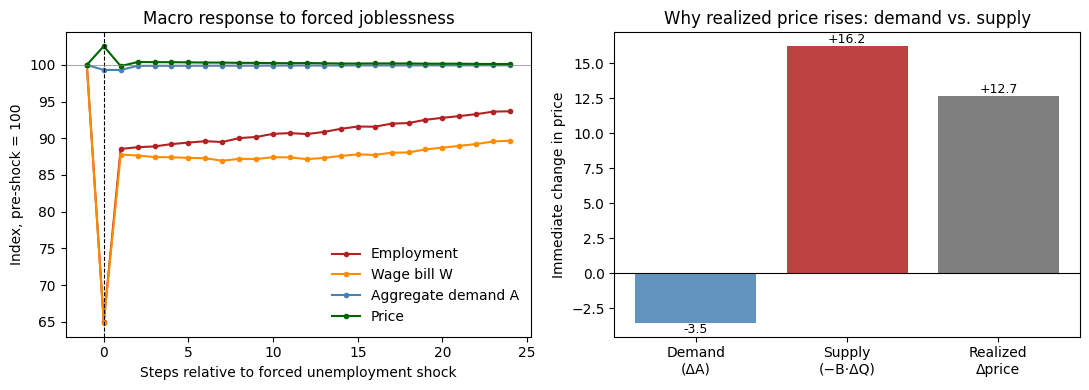


Forced unemployment shock:
  shock step: 240; shock share: 35%; follow-up: 24 steps
  workers forced jobless:   mean=110.8, min=107, max=114
  immediate Delta wage bill: mean=-2295.105
  immediate Delta A (demand):mean=-3.546   <- Keynesian channel
  immediate Delta output:    mean=-32.465
  price decomposition  dp = dA - B*dQ:
     demand component (dA):      -3.546
     supply component (-B*dQ):   +16.232
     realized Delta price:       +12.686

PASS - Pattern 4


In [9]:
SHOCK_STEP  = N_STEPS // 4      # selected moment in the run
SHOCK_SHARE = 0.35              # share of employed workers forced jobless
POST_STEPS  = 24                # follow-up window after the shock

# Demand-curve slope B, needed to split the price response into its
# demand (A) and supply (output) components. Read from the active scenario.
_p4_params = BASE_PARAMS.copy(); _p4_params.update(SCENARIO_B)
B_SLOPE = _p4_params['B']

def employment_level(m):
    return sum(1 for w in m.workers if w.employed)

def refresh_macro_state(m):
    """Recalculate output, factor incomes, demand A and price after an
    out-of-step shock, so the wage-bill fall shows up immediately."""
    for p in m.producers:
        p.produce()
        p.trim_ai_capacity()
    m.Y = m.calculate_wage_bill()
    m.Pi = m.calculate_profit_income()
    # Re-evaluate the consumption function on the freshly shocked incomes
    m.A = m.A_base + m.gamma * m.Y + m.gamma_pi * m.Pi
    m.p = m.calculate_market_price()
    m._compute_all_stats()

def snapshot(m, rep, horizon, label, n_forced=0):
    return {
        'rep': rep, 'horizon': horizon, 'label': label,
        'n_forced_jobless': n_forced,
        'employment': employment_level(m),
        'employment_rate': employment_level(m) / len(m.workers),
        'A_demand': m.A,
        'price': m.p,
        'wage_bill': m.calculate_wage_bill(),
        'profit_income': m.calculate_profit_income(),
        'total_output': sum(p.output for p in m.producers),
    }

def force_unemployment_shock(m, share, rng):
    """Force a randomly selected share of employed workers into unemployment."""
    employed = [w for w in m.workers if w.employed]
    n_shocked = max(1, int(round(share * len(employed))))
    shocked_idx = rng.choice(len(employed), size=n_shocked, replace=False)
    for i in shocked_idx:
        w = employed[int(i)]
        task, employer = w.task, w.employer
        if task is not None and w in task.employees:
            task.employees.remove(w)
        if employer is not None and w in employer.employees:
            employer.employees.remove(w)
        w.employed = False
        w.employer = None
        w.task = None
        w.wage = 0.0
    # Exogenous demand-side validation shock: no firm replacement / automation.
    for p in m.producers:
        p._pending_requests = []
    m.new_displaced_workers_this_step += n_shocked
    return n_shocked

shock_records = []
for r in range(N_REPS):
    params = BASE_PARAMS.copy()
    params.update(SCENARIO_B)
    params['seed'] = 1600 + r
    m = LabourMarketModel(**params)

    for _ in range(SHOCK_STEP):
        m.step()
    refresh_macro_state(m)
    shock_records.append(snapshot(m, r, -1, 'pre-shock'))

    rng = np.random.default_rng(1600 + r)
    n_shocked = force_unemployment_shock(m, SHOCK_SHARE, rng)
    refresh_macro_state(m)
    shock_records.append(snapshot(m, r, 0, 'forced unemployment', n_shocked))

    for h in range(1, POST_STEPS + 1):
        m.step()
        shock_records.append(snapshot(m, r, h, 'post-shock'))

shock_df = pd.DataFrame(shock_records)
pre    = shock_df[shock_df['horizon'] == -1].set_index('rep')
impact = shock_df[shock_df['horizon'] ==  0].set_index('rep')

# --- Immediate changes at the shock step --------------------------------
employment_drop = pre['employment']    - impact['employment']
dW = impact['wage_bill']    - pre['wage_bill']
dA = impact['A_demand']     - pre['A_demand']
dQ = impact['total_output'] - pre['total_output']
dp_total = impact['price']  - pre['price']

# Exact decomposition of the realized price change: dp = dA - B*dQ
price_demand_component = dA                 # demand-side pressure (constant output)
price_supply_component = -B_SLOPE * dQ      # supply-side pressure (output collapse)

mean_path = shock_df.groupby('horizon')[['employment_rate', 'wage_bill', 'A_demand', 'price']].mean()
norm_path = 100 * mean_path / mean_path.loc[-1]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Left: macro response over time (indexed to pre-shock = 100)
for col, label, color in [
    ('employment_rate', 'Employment',       'firebrick'),
    ('wage_bill',       'Wage bill W',       'darkorange'),
    ('A_demand',        'Aggregate demand A','steelblue'),
    ('price',           'Price',             'darkgreen'),
]:
    axes[0].plot(norm_path.index, norm_path[col], marker='o', ms=3, label=label, color=color)
axes[0].axvline(0, color='black', ls='--', lw=0.8)
axes[0].axhline(100, color='grey', lw=0.5)
axes[0].set_xlabel('Steps relative to forced unemployment shock')
axes[0].set_ylabel('Index, pre-shock = 100')
axes[0].set_title('Macro response to forced joblessness')
axes[0].legend(frameon=False)

# Right: decomposition of the immediate price response
labels = ['Demand\n(ΔA)', 'Supply\n(−B·ΔQ)', 'Realized\nΔprice']
values = [price_demand_component.mean(), price_supply_component.mean(), dp_total.mean()]
colors = ['steelblue', 'firebrick', 'dimgray']
bars = axes[1].bar(labels, values, color=colors, alpha=0.85)
axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_ylabel('Immediate change in price')
axes[1].set_title('Why realized price rises: demand vs. supply')
for b, v in zip(bars, values):
    axes[1].annotate(f'{v:+.1f}', (b.get_x() + b.get_width()/2, v),
                     ha='center', va='bottom' if v >= 0 else 'top', fontsize=9)

plt.tight_layout(); save_fig(fig, 'fig_5_6_keynes.png'); plt.show()

print('\nForced unemployment shock:')
print(f'  shock step: {SHOCK_STEP}; shock share: {SHOCK_SHARE:.0%}; follow-up: {POST_STEPS} steps')
print(f'  workers forced jobless:   mean={employment_drop.mean():.1f}, '
      f'min={employment_drop.min():.0f}, max={employment_drop.max():.0f}')
print(f'  immediate Delta wage bill: mean={dW.mean():+.3f}')
print(f'  immediate Delta A (demand):mean={dA.mean():+.3f}   <- Keynesian channel')
print(f'  immediate Delta output:    mean={dQ.mean():+.3f}')
print('  price decomposition  dp = dA - B*dQ:')
print(f'     demand component (dA):      {price_demand_component.mean():+.3f}')
print(f'     supply component (-B*dQ):   {price_supply_component.mean():+.3f}')
print(f'     realized Delta price:       {dp_total.mean():+.3f}')

# Verdict: the Keynesian DEMAND channel must fire (employment, wage bill and A
# all fall). The realized price is confounded by the supply collapse and is
# reported, not gated.
verdict = (employment_drop.mean() > 0) and (dW.mean() < 0) and (dA.mean() < 0)
VERDICTS[4] = ('Demand decline', 'forced unemployment lowers wage bill and A',
               verdict,
               f'dL={employment_drop.mean():.1f}, dW={dW.mean():+.2f}, '
               f'dA={dA.mean():+.3f} (demand-side dp={price_demand_component.mean():+.2f})')
print(f'\n{"PASS" if verdict else "FAIL"} - Pattern 4')

---
## Pattern 5 - Higher minimum wage pushes firms to automate

**What we test.** If labour is more expensive (high `w_min`), do firms automate more?

**How.** Sweep `w_min` over six levels and look at final AI adoption.

**Pass criterion.** Spearman correlation between `w_min` and final adoption is positive.


  figure saved: fig_5_8_min_wage.png


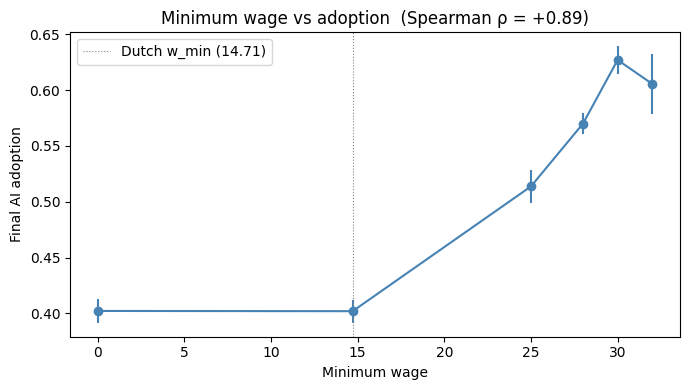


Spearman: ρ = +0.89 (p = 0.019)

PASS - Pattern 5


In [6]:
wmin_levels = [0, 14.71, 25, 28, 30, 32]   # 14.71 = Dutch statutory minimum hourly wage (2026)
end_adoption = {}
for w in wmin_levels:
    runs = run_sims({**SCENARIO_B, 'w_min': w}, seed_base=1700)
    end_adoption[w] = np.array([df['ai_adoption_rate'].iloc[-1] for df in runs])

means = [end_adoption[w].mean() for w in wmin_levels]
stds  = [end_adoption[w].std()  for w in wmin_levels]
rho, p = stats.spearmanr(wmin_levels, means)

fig, ax = plt.subplots(figsize=(7, 4))
ax.errorbar(wmin_levels, means, yerr=stds, fmt='o-', color='steelblue')
ax.axvline(14.71, color='grey', ls=':', lw=0.8, label='Dutch w_min (14.71)')
ax.set_xlabel('Minimum wage'); ax.set_ylabel('Final AI adoption')
ax.set_title(f'Minimum wage vs adoption  (Spearman ρ = {rho:+.2f})')
ax.legend()
plt.tight_layout(); save_fig(fig, 'fig_5_8_min_wage.png'); plt.show()

print(f'\nSpearman: ρ = {rho:+.2f} (p = {p:.2g})')

verdict = rho > 0
VERDICTS[5] = ('Minimum wage vs adoption', 'ρ > 0', verdict, f'ρ={rho:+.2f}, p={p:.2g}')
print(f'\n{"PASS" if verdict else "FAIL"} - Pattern 5')

---
## Pattern 6 - Polarisation depends on what AI is good at

**What we test.** When AI is *better at routine tasks* (low `nr_multiplier`), low-skilled workers should be hit harder. We look at two signals:
1. **Skill wage premium** $w_h / w_l$ - should widen at low `nr_multiplier`.
2. **Routine share of automation** - share of automated tasks that are routine. Should be higher at low `nr_multiplier`.

**Pass criterion.** Either signal moves the expected way (premium wider OR routine share higher at low μ).


  figure saved: fig_5_9_polarisation.png


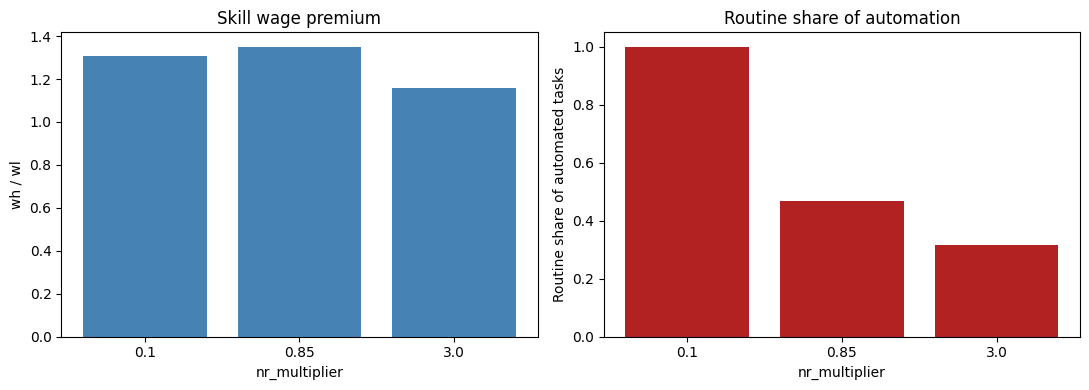


By nr_multiplier:
  μ=0.1: premium = 1.307, routine_share = 1.000
  μ=0.85: premium = 1.350, routine_share = 0.467
  μ=3.0: premium = 1.157, routine_share = 0.316

PASS - Pattern 6


In [7]:
mu_levels = [0.1, 0.85, 3.0]   # AI strongly favours routine / neutral / AI favours non-routine
results = {}
for mu in mu_levels:
    runs = run_sims({**SCENARIO_B, 'nr_multiplier': mu, 'w_min': 0.0}, seed_base=1900)
    premium_list, routine_share_list = [], []
    for rep, df in enumerate(runs):
        w_l_end = df['wage_low'].iloc[-1]
        w_h_end = df['wage_high'].iloc[-1]
        if w_l_end > 0:
            premium_list.append(w_h_end / w_l_end)
    for r in range(N_REPS):
        params = BASE_PARAMS.copy()
        params.update({**SCENARIO_B, 'nr_multiplier': mu, 'w_min': 0.0})
        params['seed'] = 1900 + r
        m = LabourMarketModel(**params)
        for _ in range(N_STEPS):
            m.step()
        nr  = sum(1 for p in m.producers for t in p.tasks if t.automated and t.task_type == 'routine')
        nnr = sum(1 for p in m.producers for t in p.tasks if t.automated and t.task_type == 'non_routine')
        if (nr + nnr) > 0:
            routine_share_list.append(nr / (nr + nnr))
    results[mu] = dict(premium=float(np.mean(premium_list)) if premium_list else float('nan'),
                       routine_share=float(np.mean(routine_share_list)) if routine_share_list else float('nan'))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
mus = list(results.keys())
ax[0].bar([str(m) for m in mus], [results[m]['premium'] for m in mus], color='steelblue')
ax[0].set_xlabel('nr_multiplier'); ax[0].set_ylabel('wh / wl')
ax[0].set_title('Skill wage premium')
ax[1].bar([str(m) for m in mus], [results[m]['routine_share'] for m in mus], color='firebrick')
ax[1].set_xlabel('nr_multiplier'); ax[1].set_ylabel('Routine share of automated tasks')
ax[1].set_title('Routine share of automation')
plt.tight_layout(); save_fig(fig, 'fig_5_9_polarisation.png'); plt.show()

print('\nBy nr_multiplier:')
for mu in mus:
    print(f'  μ={mu}: premium = {results[mu]["premium"]:.3f}, routine_share = {results[mu]["routine_share"]:.3f}')

prem_ok = results[mus[0]]['premium']       > results[mus[-1]]['premium']
rs_ok   = results[mus[0]]['routine_share'] > results[mus[-1]]['routine_share']
verdict = prem_ok or rs_ok
VERDICTS[6] = ('Polarisation', 'low μ → wider premium OR more routine automati  on', verdict,
               f'premium widens: {prem_ok}, routine share rises: {rs_ok}')
print(f'\n{"PASS" if verdict else "FAIL"} - Pattern 6')

---
## Synthesis

One summary table showing PASS/FAIL for each pattern, plus a one-liner of evidence.


In [8]:
rows = []
for k in sorted(VERDICTS.keys()):
    name, expected, ok, evidence = VERDICTS[k]
    rows.append([k, name, expected, 'PASS' if ok else 'FAIL', evidence])

table = pd.DataFrame(rows, columns=['#', 'Pattern', 'Expected', 'Result', 'Evidence'])
print('Validation summary')
print('=' * 80)
print(table.to_string(index=False))

n_pass = sum(1 for v in VERDICTS.values() if v[2])
print(f'\nOverall: {n_pass} / {len(VERDICTS)} patterns PASS  '
      f'(N_REPS={N_REPS}, N_STEPS={N_STEPS})')

Validation summary
 #                  Pattern                                           Expected Result                                                                          Evidence
 1       Profitability gate           forced AC > p stops proactive automation   PASS AC>p share=100%; profit<0 share=100%; gate blocks=20.0/step; new proactive auto=0
 2      AI cost vs adoption                           cheap AI → more adoption   PASS                                        floor monotone: True, decay monotone: True
 3    Severance vs adoption                 high severance → not more adoption   PASS                                                    no-sev: 0.413, high-sev: 0.387
 4           Demand decline             forced unemployment lowers A and price   FAIL                                                   dL=110.8, dA=-3.546, dp=+12.686
 5 Minimum wage vs adoption                                              ρ > 0   PASS                                                        